# 🤖 Clasificación Kmeans
### Machine Learning

**👨‍🎓 Alumno:** Luis Angel Flores Espinosa  
**🆔 Matrícula:** 210110157  
**🏫 Institución:** Tecnológico Superior de Jalisco  

# Importación de librerías

Antes de implementar el algoritmo K-Means, es necesario importar las librerías que permitirán trabajar con:

- conjuntos de datos
- operaciones matemáticas
- visualización de información
- algoritmos de clustering

Cada librería cumple una función específica dentro del proceso de agrupamiento de datos.

En este paso se importarán las herramientas necesarias para:

- cargar el DataSet Iris
- aplicar el algoritmo K-Means
- manipular datos
- generar gráficas
- realizar operaciones numéricas

In [1]:
# Importar el DataSet Iris desde sklearn.datasets
# Este DataSet será utilizado para aplicar K-Means
from sklearn.datasets import load_iris

# Importar el algoritmo K-Means
# desde sklearn.cluster
from sklearn.cluster import KMeans

# Importar matplotlib para crear gráficas
# y visualizar los clusters
import matplotlib.pyplot as plt

# Importar NumPy para realizar
# operaciones matemáticas y numéricas
import numpy as np

# Importar Pandas para manipular
# y analizar datos en forma de tablas
import pandas as pd

## Carga y preparación del DataSet Iris

Después de importar las librerías necesarias, el siguiente paso consiste en cargar el DataSet Iris.

El DataSet Iris es uno de los conjuntos de datos más utilizados en Machine Learning y contiene información sobre diferentes especies de flores.

Cada registro incluye características como:

- longitud del sépalo
- ancho del sépalo
- longitud del pétalo
- ancho del pétalo

Posteriormente, los datos serán convertidos en un DataFrame de Pandas para facilitar su manipulación y análisis.

Finalmente, se agregará la columna `target`, la cual representa la clase o especie de cada flor, y se mostrarán las primeras filas del DataSet para verificar que la información fue cargada correctamente.

In [2]:
# Cargar el DataSet Iris
# y guardarlo en la variable iris
iris = load_iris()

# Crear un DataFrame utilizando:
# iris.data -> contiene las características numéricas
# iris.feature_names -> contiene los nombres de las columnas
iris_df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)

# Agregar una nueva columna llamada 'target'
# que contiene la clase o especie de cada flor
iris_df['target'] = iris.target

# Mostrar las primeras 5 filas del DataSet
# para verificar que los datos fueron cargados correctamente
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Creación y entrenamiento del modelo K-Means

Después de preparar el DataSet, el siguiente paso consiste en crear y entrenar el modelo de clustering utilizando el algoritmo K-Means.

K-Means es un algoritmo de aprendizaje no supervisado que agrupa los datos en diferentes clusters basándose en la similitud entre registros.

El algoritmo funciona de la siguiente manera:

1. Selecciona una cantidad de clusters (`K`)
2. Inicializa centroides
3. Calcula distancias entre los datos y los centroides
4. Asigna cada dato al centroide más cercano
5. Recalcula los centroides
6. Repite el proceso hasta alcanzar convergencia

En este caso:

- Se crearán 3 clusters
- Se utilizará el método `k-means++` para inicializar centroides
- El algoritmo podrá realizar hasta 300 iteraciones
- Se utilizará una semilla para obtener resultados reproducibles

Finalmente, se mostrarán las etiquetas de cluster asignadas a cada registro.

In [3]:
# Crear el modelo K-Means
kmeans = KMeans(

    # Número de clusters que se desean crear
    n_clusters=3,

    # Método de inicialización de centroides
    # k-means++ ayuda a mejorar la distribución inicial
    init='k-means++',

    # Número máximo de iteraciones permitidas
    # para que el algoritmo encuentre convergencia
    max_iter=300,

    # Semilla para obtener resultados reproducibles
    random_state=0
)

# Entrenar el modelo utilizando
# los datos del DataSet Iris
kmeans.fit(iris.data)

# Mostrar las etiquetas asignadas por K-Means
# Cada número representa el cluster
# al que pertenece cada registro
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


## Asignación de clusters y análisis de resultados

Después de entrenar el modelo K-Means, cada registro del DataSet recibe una etiqueta que indica el cluster al que fue asignado.

En este paso:

1. Se agregará una nueva columna llamada `cluster` al DataFrame
2. Dicha columna almacenará el número de cluster asignado por el algoritmo
3. Posteriormente, se realizará una agrupación para comparar:
   - la clase real (`target`)
   - el cluster asignado por K-Means

Este análisis permite observar qué tan bien logró el algoritmo separar las diferentes especies del DataSet Iris.

In [4]:
# Crear una nueva columna llamada 'cluster'
# dentro del DataFrame
# Esta columna almacenará el cluster asignado
# a cada registro por el algoritmo K-Means
iris_df['cluster'] = kmeans.labels_

# Agrupar los datos utilizando:
# target  -> clase real de la flor
# cluster -> cluster asignado por K-Means
#
# agg({'sepal length (cm)':'count'})
# cuenta cuántos registros existen
# en cada combinación de target y cluster
iris_df.groupby(
    ['target', 'cluster']
).agg({
    'sepal length (cm)': 'count'
})

sepal length (cm)
target cluster                   
0      1                       50
1      0                       47
       2                        3
2      0                       14
       2                       36

## Reducción de dimensionalidad con PCA

El DataSet Iris contiene varias características numéricas, lo que dificulta visualizar los datos directamente en una gráfica de dos dimensiones.

Por esta razón, se utilizará la técnica PCA (Principal Component Analysis), la cual permite reducir la cantidad de dimensiones del DataSet conservando la mayor cantidad posible de información importante.

En este paso:

1. Se aplicará PCA para reducir los datos a 2 dimensiones
2. Se generarán dos nuevos componentes principales
3. Los resultados serán almacenados en nuevas columnas llamadas `X` y `Y`
4. Finalmente, se mostrarán las primeras filas del DataFrame

Estas nuevas dimensiones permitirán visualizar los clusters generados por K-Means en una gráfica bidimensional.

In [5]:
# Importar la técnica PCA
# desde sklearn.decomposition
from sklearn.decomposition import PCA

# Crear el modelo PCA indicando
# que los datos serán reducidos
# a 2 dimensiones
pca = PCA(2)

# Aplicar PCA al DataSet Iris
# fit_transform() realiza:
# 1. El entrenamiento del modelo PCA
# 2. La transformación de los datos
pca_res = pca.fit_transform(iris.data)

# Crear una nueva columna llamada 'X'
# utilizando el primer componente principal
iris_df['X'] = pca_res[:, 0]

# Crear una nueva columna llamada 'Y'
# utilizando el segundo componente principal
iris_df['Y'] = pca_res[:, 1]

# Mostrar las primeras filas del DataFrame
# para verificar las nuevas columnas
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster,X,Y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755


## Visualización de los clusters generados por K-Means

Después de aplicar el algoritmo K-Means y reducir las dimensiones del DataSet utilizando PCA, el siguiente paso consiste en visualizar gráficamente los clusters obtenidos.

La visualización permite observar cómo el algoritmo agrupó los datos y qué tan separadas se encuentran las diferentes agrupaciones.

En este paso:

1. Se separarán los registros de cada cluster
2. Se creará una gráfica de dispersión
3. Cada cluster será representado con diferentes puntos
4. Se agregarán etiquetas y títulos para mejorar la interpretación de la gráfica

La gráfica final mostrará la distribución de los clusters utilizando las dos dimensiones generadas por PCA (`X` y `Y`).

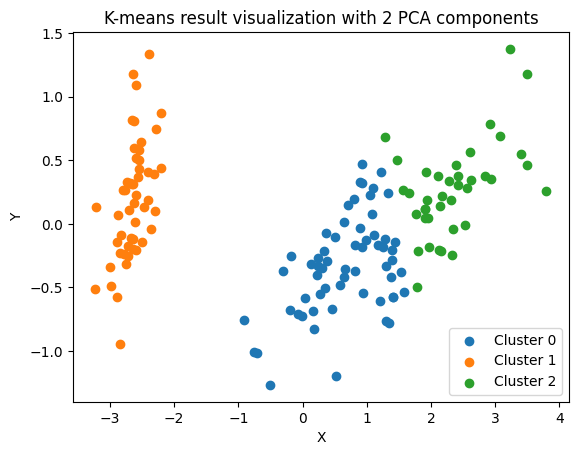

In [6]:
# Crear un DataFrame únicamente con los registros
# pertenecientes al Cluster 0
cluster_0 = iris_df[iris_df['cluster'] == 0]

# Crear un DataFrame únicamente con los registros
# pertenecientes al Cluster 1
cluster_1 = iris_df[iris_df['cluster'] == 1]

# Crear un DataFrame únicamente con los registros
# pertenecientes al Cluster 2
cluster_2 = iris_df[iris_df['cluster'] == 2]

# Crear una gráfica de dispersión para el Cluster 0
# utilizando las coordenadas X y Y
plt.scatter(
    cluster_0['X'],
    cluster_0['Y'],
    label='Cluster 0'
)

# Crear una gráfica de dispersión para el Cluster 1
plt.scatter(
    cluster_1['X'],
    cluster_1['Y'],
    label='Cluster 1'
)

# Crear una gráfica de dispersión para el Cluster 2
plt.scatter(
    cluster_2['X'],
    cluster_2['Y'],
    label='Cluster 2'
)

# Mostrar la leyenda de la gráfica
plt.legend()

# Agregar título a la gráfica
plt.title('K-means result visualization with 2 PCA components')

# Etiqueta del eje X
plt.xlabel('X')

# Etiqueta del eje Y
plt.ylabel('Y')

# Mostrar la gráfica final
plt.show()